# 02 · Targeted 36k COCO VWW teacher at 160×160

**Single responsibility:** measure how much accuracy is recovered by expanding the 160×160 teacher from 12,000 to a targeted 36,000-image COCO-2017 curriculum within a practical download budget.

This is deliberately not a deployment notebook. Architecture, preprocessing, augmentation, validation IDs, test IDs, threshold selection, and fine-tuning policy remain identical to Notebook 01. The training intervention is pre-registered: retain the existing 12k rows, include every eligible small-person image, and build a balanced 18k-person / 18k-no-person curriculum.

## Evidence flow

COCO-2017 annotations + Notebook 01 reference manifest
→ targeted 36k training curriculum + frozen validation/test IDs
→ download/validate missing native JPEGs
→ dataset-scale and visibility audit
→ aspect-preserving 160×160 RGB letterbox
→ training-only OV3660-like augmentation
→ ImageNet MobileNetV1 α=0.50
→ frozen-head training
→ selective late-layer fine-tuning
→ validation threshold and calibration
→ one-time held-out test
→ cached probabilities for student distillation

Primary architecture context: [MobileNets](https://arxiv.org/abs/1704.04861) and [Visual Wake Words](https://arxiv.org/abs/1906.05721).

## 1 · Locate the repository and isolate framework caches

The notebook works from the repository root or this directory. Cache paths stay outside versioned outputs.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/vww-matplotlib")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")

current = Path.cwd().resolve()
ROOT = next(candidate for candidate in (current, *current.parents) if (candidate / "pyproject.toml").exists())
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
print(f"Repository: {ROOT}")


Repository: /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32


## 2 · Import deterministic experiment dependencies

Project helpers preserve the metric and threshold definitions used by the previous experiments.

In [2]:
import hashlib
import json
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import yaml
from IPython.display import Markdown, display
from sklearn.metrics import precision_recall_curve, roc_curve

from vww_esp32.config import seed_everything
from vww_esp32.data import build_manifest, download_manifest_images, validate_images
from vww_esp32.evaluation import classification_metrics, expected_calibration_error, select_threshold
from vww_esp32.profiling import profile_model

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)


/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3 · Register the experiment before observing results

The configuration freezes resolution, geometry, architecture, optimization stages, and acceptance gates. Run All performs training when checkpoints do not exist and reuses validation-selected checkpoints on later runs.

In [3]:
CONFIG_PATH = ROOT / "configs/teacher_160_targeted_36k.yaml"
with CONFIG_PATH.open(encoding="utf-8") as handle:
    config = yaml.safe_load(handle)

SEED = int(config["project"]["seed"])
IMAGE_SIZE = tuple(config["preprocessing"]["image_size"])
BATCH_SIZE = int(config["preprocessing"]["batch_size"])
ARTIFACT_DIR = ROOT / config["paths"]["artifacts"]
REPORT_DIR = ARTIFACT_DIR / "reports"
FIGURE_DIR = ARTIFACT_DIR / "figures"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
MODEL_DIR = ARTIFACT_DIR / "models"
for directory in (REPORT_DIR, FIGURE_DIR, CHECKPOINT_DIR, MODEL_DIR, ARTIFACT_DIR / "logs"):
    directory.mkdir(parents=True, exist_ok=True)

RUN_TRAINING = True
REUSE_BEST_CHECKPOINT = True
seed_everything(SEED)
print({"image_size": IMAGE_SIZE, "batch_size": BATCH_SIZE, "run_training": RUN_TRAINING})


{'image_size': (160, 160), 'batch_size': 32, 'run_training': True}


## 4 · Build the controlled targeted-COCO manifest

This block first indexes the complete COCO `train2017` annotation pool without downloading images. It preserves all 12,000 existing training IDs, includes every eligible small-person image, fills medium and large positive strata deterministically, and samples negatives to produce exactly 18,000 positives and 18,000 negatives. The exact Notebook 01 validation/test rows remain frozen. Set `REBUILD_MANIFEST=True` only when intentionally changing this contract.

In [4]:
REBUILD_MANIFEST = False
MANIFEST_PATH = ROOT / config["data"]["manifest"]
REFERENCE_MANIFEST_PATH = ROOT / config["data"]["reference_manifest"]
TRAIN_ANNOTATIONS = ROOT / config["data"]["train_annotations"]
TEST_ANNOTATIONS = ROOT / config["data"]["test_annotations"]
IMAGE_ROOT = ROOT / config["data"]["image_root"]

for required_path in (REFERENCE_MANIFEST_PATH, TRAIN_ANNOTATIONS, TEST_ANNOTATIONS):
    assert required_path.exists(), f"Missing prerequisite: {required_path}"

if MANIFEST_PATH.exists() and not REBUILD_MANIFEST:
    manifest = pd.read_csv(MANIFEST_PATH)
    print(f"Reused frozen targeted-data manifest: {MANIFEST_PATH}")
else:
    complete_pool = build_manifest(
        TRAIN_ANNOTATIONS,
        TEST_ANNOTATIONS,
        image_root=IMAGE_ROOT,
        min_area_fraction=float(config["data"]["min_person_area_fraction"]),
        validation_fraction=float(config["data"]["validation_fraction"]),
        max_samples={"train": None, "val": None, "test": None},
        balance_training_classes=False,
        seed=SEED,
    )
    reference = pd.read_csv(REFERENCE_MANIFEST_PATH)
    reference_train_ids = set(reference.loc[reference.split == "train", "image_id"])
    frozen_validation_ids = set(reference.loc[reference.split == "val", "image_id"])
    candidate_train = complete_pool[
        (complete_pool.source_split == "train2017")
        & (~complete_pool.image_id.isin(frozen_validation_ids))
    ].copy()
    candidate_train["split"] = "train"

    area = candidate_train.max_person_area_fraction
    minimum_area = float(config["data"]["min_person_area_fraction"])
    small_limit = float(config["data"]["small_person_max_area_fraction"])
    positive_strata = {
        "small": candidate_train[(candidate_train.label == 1) & (area >= minimum_area) & (area < small_limit)],
        "medium": candidate_train[(candidate_train.label == 1) & (area >= small_limit) & (area < 0.10)],
        "large": candidate_train[(candidate_train.label == 1) & (area >= 0.10)],
    }

    def deterministic_selection(frame, target, mandatory_ids, seed):
        mandatory = frame[frame.image_id.isin(mandatory_ids)]
        assert len(mandatory) <= target, (len(mandatory), target)
        candidates = frame[~frame.image_id.isin(mandatory.image_id)]
        needed = target - len(mandatory)
        assert len(candidates) >= needed, (len(candidates), needed)
        sampled = candidates.sample(n=needed, random_state=seed) if needed else candidates.iloc[:0]
        return pd.concat([mandatory, sampled], ignore_index=True)

    small_positive = positive_strata["small"].copy()
    assert bool(config["data"]["include_all_small_person"]), "This experiment requires all small positives"
    medium_positive = deterministic_selection(
        positive_strata["medium"],
        int(config["data"]["target_medium_positive_samples"]),
        reference_train_ids, SEED + 101,
    )
    large_positive = deterministic_selection(
        positive_strata["large"],
        int(config["data"]["target_large_positive_samples"]),
        reference_train_ids, SEED + 102,
    )
    negatives = deterministic_selection(
        candidate_train[candidate_train.label == 0],
        int(config["data"]["target_negative_samples"]),
        reference_train_ids, SEED + 103,
    )
    targeted_train = pd.concat(
        [small_positive, medium_positive, large_positive, negatives],
        ignore_index=True, sort=False,
    ).drop_duplicates("image_id")
    targeted_train["split"] = "train"
    frozen_holdout = reference[reference.split.isin(["val", "test"])].copy()
    manifest = pd.concat([targeted_train, frozen_holdout], ignore_index=True, sort=False)
    manifest = manifest.sort_values(["split", "image_id"]).reset_index(drop=True)

    assert manifest.image_id.is_unique
    assert set(manifest.split) == {"train", "val", "test"}
    selected_train = manifest[manifest.split == "train"]
    assert len(selected_train) == int(config["data"]["target_train_samples"])
    assert int(selected_train.label.sum()) == int(config["data"]["target_positive_samples"])
    assert int((selected_train.label == 0).sum()) == int(config["data"]["target_negative_samples"])
    assert reference_train_ids.issubset(set(selected_train.image_id)), (
        "Every Notebook 01 training image must remain in the expanded curriculum"
    )
    assert set(small_positive.image_id).issubset(set(selected_train.image_id))
    for split_name in ("val", "test"):
        expected = set(reference.loc[reference.split == split_name, "image_id"])
        observed = set(manifest.loc[manifest.split == split_name, "image_id"])
        assert observed == expected, f"{split_name} IDs changed"
    MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
    manifest.to_csv(MANIFEST_PATH, index=False)
    print(f"Created controlled targeted-data manifest: {MANIFEST_PATH}")

manifest.groupby(["split", "label"]).size().rename("images").to_frame()


Reused frozen targeted-data manifest: /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/data/processed/manifest_teacher_160_targeted_36k.csv


images
split label        
test  0        1019
      1         981
train 0       18000
      1       18000
val   0        1011
      1         989

## 5 · Acquire and validate missing COCO images

The repository already contains all 12,000 reference training images and both frozen holdouts. This cell therefore downloads only the approximately 24,000 newly selected JPEGs—not the 18 GiB archive or complete COCO collection. Existing files are verified and reused. Rerunning safely skips valid images and retries failures.

In [5]:
DOWNLOAD_MISSING_IMAGES = True
missing_before = ~manifest.image_path.map(lambda value: Path(value).exists())
existing_sizes = manifest.loc[~missing_before, "image_path"].map(lambda value: Path(value).stat().st_size)
estimated_download_gib = (
    float(existing_sizes.mean()) * int(missing_before.sum()) / (1024 ** 3)
    if len(existing_sizes) else np.nan
)
download_audit = {
    "total_images": int(len(manifest)),
    "existing_images": int((~missing_before).sum()),
    "missing_images": int(missing_before.sum()),
    "estimated_remaining_download_gib": estimated_download_gib,
}
display(pd.Series(download_audit))

if missing_before.any() and DOWNLOAD_MISSING_IMAGES:
    manifest = download_manifest_images(
        manifest,
        workers=int(config["data"]["download_workers"]),
        timeout=int(config["data"]["download_timeout_seconds"]),
    )
    failures = manifest.attrs.get("failures", [])
    manifest.to_csv(MANIFEST_PATH, index=False)
    assert not failures, f"{len(failures)} downloads failed; rerun this cell to retry"

missing_after = ~manifest.image_path.map(lambda value: Path(value).exists())
assert not missing_after.any(), (
    f"{int(missing_after.sum())} images are missing. "
    "Enable DOWNLOAD_MISSING_IMAGES and rerun this cell."
)
validated = validate_images(manifest)
invalid = validated[~validated.valid]
assert invalid.empty, f"{len(invalid)} corrupt images found; remove them and rerun download"
print(f"Validated {len(validated):,} native COCO JPEGs")


total_images                        40000.0
existing_images                     40000.0
missing_images                          0.0
estimated_remaining_download_gib        0.0
dtype: float64

Validate: 100%|██████████| 40000/40000 [00:09<00:00, 4131.40it/s]


Validated 40,000 native COCO JPEGs


## 6 · Verify the scale and targeted sampling intervention

The chart reports actual row counts, binary balance, and positive person-size composition. Validation and test IDs must match Notebook 01 exactly. Training grows from 12,000 to 36,000 images, remains 50/50 person versus no-person, and deliberately increases small-person coverage because that was the teacher's weakest test slice.

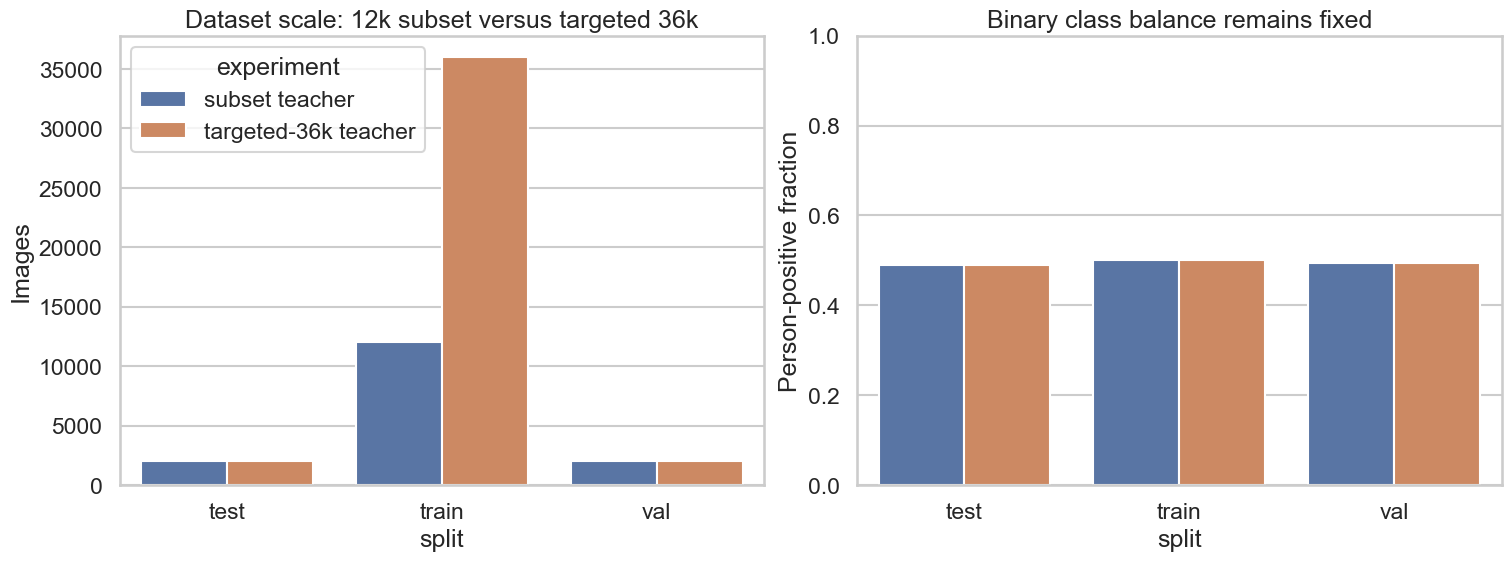

,experiment,split,samples,positive_fraction
0,subset teacher,test,2000,49.05%
1,subset teacher,train,12000,50.00%
2,subset teacher,val,2000,49.45%
3,targeted-36k teacher,test,2000,49.05%
4,targeted-36k teacher,train,36000,50.00%
5,targeted-36k teacher,val,2000,49.45%


,person_size,images
0,small,7662
1,medium,5169
2,large,5167


In [6]:
reference = pd.read_csv(REFERENCE_MANIFEST_PATH)
scale_rows = []
for experiment_name, frame in (("subset teacher", reference), ("targeted-36k teacher", manifest)):
    for split_name, group in frame.groupby("split"):
        scale_rows.append({
            "experiment": experiment_name,
            "split": split_name,
            "samples": len(group),
            "positive_fraction": group.label.mean(),
        })
dataset_scale = pd.DataFrame(scale_rows)
dataset_scale.to_csv(REPORT_DIR / "dataset_scale_comparison.csv", index=False)

for split_name in ("val", "test"):
    old_ids = set(reference.loc[reference.split == split_name, "image_id"])
    new_ids = set(manifest.loc[manifest.split == split_name, "image_id"])
    assert old_ids == new_ids

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
sns.barplot(data=dataset_scale, x="split", y="samples", hue="experiment", ax=axes[0])
axes[0].set(title="Dataset scale: 12k subset versus targeted 36k", ylabel="Images")
sns.barplot(data=dataset_scale, x="split", y="positive_fraction", hue="experiment", ax=axes[1])
axes[1].set(title="Binary class balance remains fixed", ylabel="Person-positive fraction", ylim=(0, 1))
axes[1].get_legend().remove()
fig.savefig(FIGURE_DIR / "dataset_scale_contract.png", dpi=180)
plt.show()
display(dataset_scale.style.format({"positive_fraction": "{:.2%}"}))

positive_train = manifest[(manifest.split == "train") & (manifest.label == 1)].copy()
positive_train["person_size"] = pd.cut(
    positive_train.max_person_area_fraction,
    bins=[float(config["data"]["min_person_area_fraction"]), 0.025, 0.10, 1.0],
    labels=["small", "medium", "large"], include_lowest=True, right=False,
)
size_audit = positive_train.groupby("person_size", observed=True).size().rename("images").reset_index()
size_audit.to_csv(REPORT_DIR / "positive_person_size_composition.csv", index=False)
display(size_audit)


## 7 · Freeze file identity and runtime metadata

The manifest digest prevents silent split or label changes from being mistaken for a resolution improvement.

In [7]:
def sha256_file(path: Path, chunk_bytes: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_bytes), b""):
            digest.update(chunk)
    return digest.hexdigest()

MANIFEST_PATH = ROOT / config["data"]["manifest"]
assert MANIFEST_PATH.exists(), f"Missing manifest: {MANIFEST_PATH}"
runtime_contract = {
    "config_sha256": sha256_file(CONFIG_PATH),
    "manifest_sha256": sha256_file(MANIFEST_PATH),
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
    "seed": SEED,
    "image_size": list(IMAGE_SIZE),
    "geometry": config["preprocessing"]["geometry"],
}
(REPORT_DIR / "runtime_contract.json").write_text(json.dumps(runtime_contract, indent=2) + "\n")
runtime_contract


{'config_sha256': 'dff1f41738e651876578dc04c81b1740b20fe27a377bc7d5a569025d744e5734',
 'manifest_sha256': 'cc136c642e8aeaa04b47f2de6db811a6537e20a3b91e5b983da096f05fa4c1cc',
 'python': '3.10.13',
 'tensorflow': '2.20.0',
 'seed': 42,
 'image_size': [160, 160],
 'geometry': 'letterbox'}

## 8 · Audit the frozen data contract

Source JPEGs remain at native resolution. The 0.5% VWW label rule is unchanged, and the exact Notebook 01 validation/test rows are retained.

In [8]:
manifest = pd.read_csv(MANIFEST_PATH)
required = {
    "image_id", "image_path", "split", "label", "width", "height",
    "aspect_ratio", "max_person_area_fraction",
}
assert required <= set(manifest.columns), required - set(manifest.columns)
assert manifest["image_path"].map(lambda value: Path(value).exists()).all(), "Some source JPEGs are missing"
assert set(manifest["split"].unique()) == {"train", "val", "test"}

split_summary = manifest.groupby("split").agg(
    samples=("image_id", "size"),
    positives=("label", "sum"),
)
split_summary["positive_fraction"] = split_summary["positives"] / split_summary["samples"]
split_summary.to_csv(REPORT_DIR / "dataset_split_summary.csv")
split_summary


,samples,positives,positive_fraction
split,,,
test,2000,981,0.4905
train,36000,18000,0.5000
val,2000,989,0.4945


## 9 · Visualize the information and label-visibility budget

The person-area chart is a proxy derived from annotations, not a reconstructed box. It makes the risk of tiny positive labels explicit.

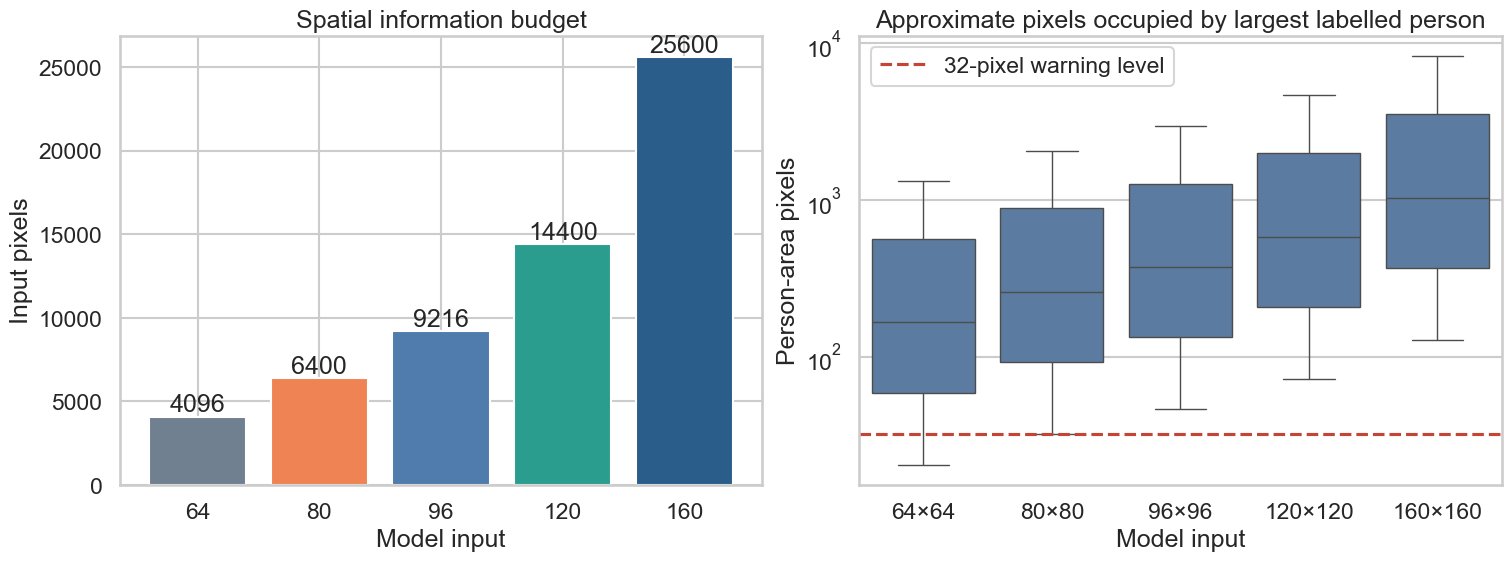

In [9]:
resolutions = np.array([64, 80, 96, 120, 160])
pixel_counts = resolutions ** 2
positive_train = manifest[(manifest.split == "train") & (manifest.label == 1)].copy()
visibility = pd.DataFrame({
    f"{size}×{size}": positive_train.max_person_area_fraction * size * size
    for size in resolutions
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
colors = ["#708090", "#ef8354", "#4f7cac", "#2a9d8f", "#2b5d8a"]
axes[0].bar(resolutions.astype(str), pixel_counts, color=colors)
axes[0].set(title="Spatial information budget", xlabel="Model input", ylabel="Input pixels")
axes[0].bar_label(axes[0].containers[0], fmt="%d")
sns.boxplot(data=visibility, ax=axes[1], color="#4f7cac", showfliers=False)
axes[1].axhline(32, color="#c44536", linestyle="--", label="32-pixel warning level")
axes[1].set(
    title="Approximate pixels occupied by largest labelled person",
    xlabel="Model input", ylabel="Person-area pixels", yscale="log",
)
axes[1].legend()
fig.savefig(FIGURE_DIR / "resolution_visibility_budget.png", dpi=180)
plt.show()


## 10 · Build an aspect-ratio-preserving input pipeline

Letterboxing preserves the complete scene, avoiding the label corruption that can occur when a crop removes the only person. Pixel normalization stays in the model.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

def decode_letterbox(path, label):
    image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    image = tf.image.resize_with_pad(
        image,
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        method=config["preprocessing"]["resize_method"],
        antialias=bool(config["preprocessing"]["antialias"]),
    )
    image = tf.cast(tf.clip_by_value(image, 0, 255), tf.float32)
    image.set_shape((*IMAGE_SIZE, 3))
    return image, tf.cast(label, tf.float32)

def make_teacher_dataset(frame, training=False, batch_size=BATCH_SIZE):
    paths = frame.image_path.astype(str).to_numpy()
    labels = frame.label.astype("float32").to_numpy()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    options = tf.data.Options()
    options.experimental_deterministic = not training
    dataset = dataset.with_options(options)
    if training:
        dataset = dataset.shuffle(
            min(len(frame), int(config["preprocessing"]["shuffle_buffer"])),
            seed=SEED, reshuffle_each_iteration=True,
        )
    dataset = dataset.map(decode_letterbox, num_parallel_calls=AUTOTUNE)
    return dataset.batch(batch_size).prefetch(AUTOTUNE)

splits = {
    name: manifest[manifest.split == name].reset_index(drop=True)
    for name in ("train", "val", "test")
}
train_ds = make_teacher_dataset(splits["train"], training=True)
train_eval_ds = make_teacher_dataset(splits["train"], training=False)
val_ds = make_teacher_dataset(splits["val"], training=False)
test_ds = make_teacher_dataset(splits["test"], training=False)

images, labels = next(iter(train_eval_ds))
assert images.shape[1:] == (*IMAGE_SIZE, 3) and images.dtype == tf.float32
print(images.shape, float(tf.reduce_min(images)), float(tf.reduce_max(images)))


(32, 160, 160, 3) 0.0 255.0


## 11 · Inspect exact model inputs before training

This catches RGB order, geometry, padding, decoding, and label errors before they become model errors.

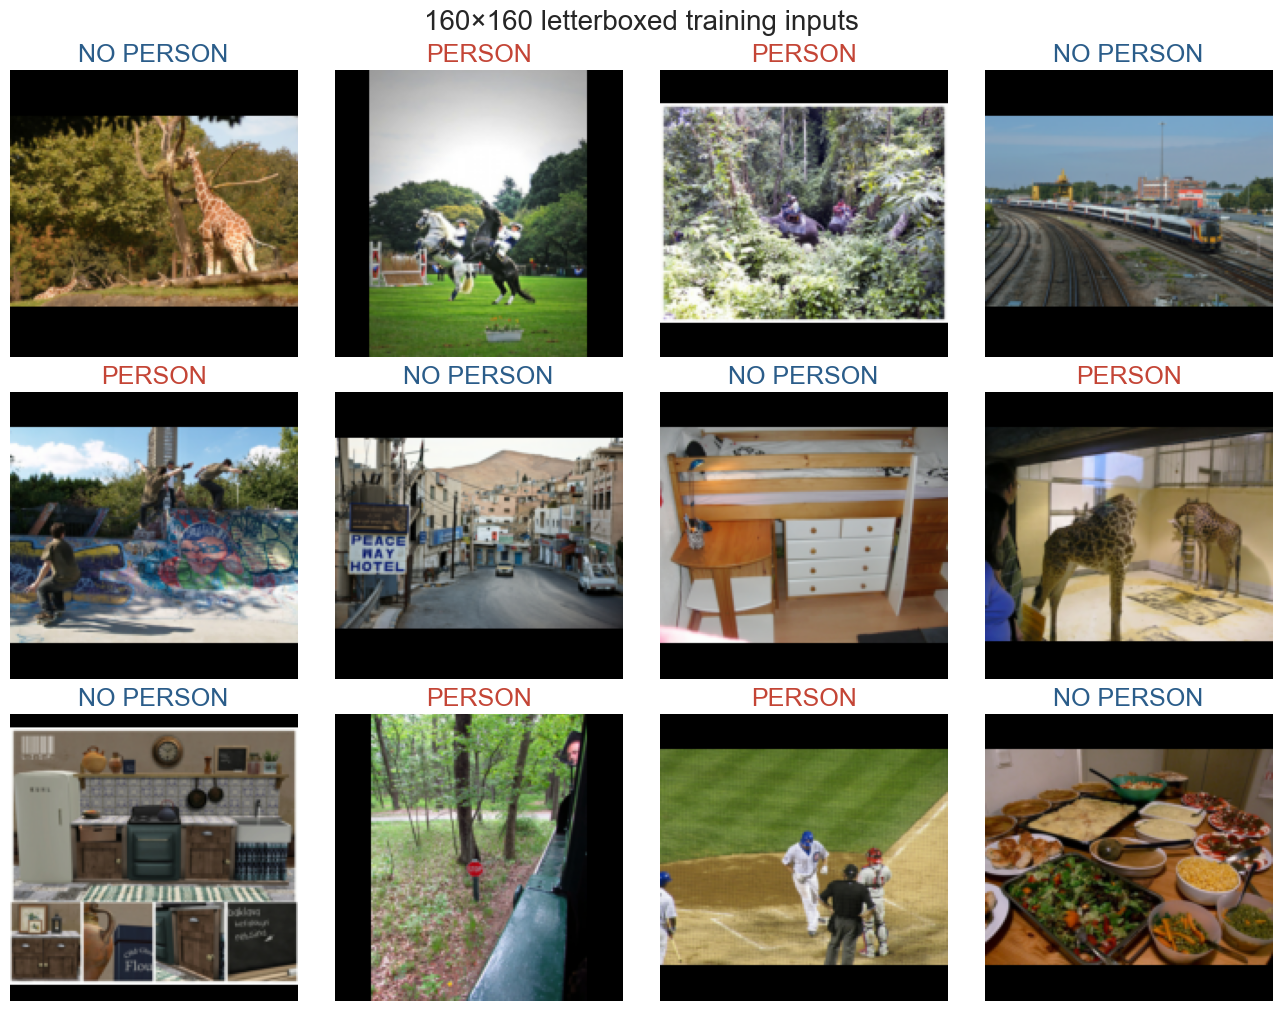

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(13, 10), constrained_layout=True)
for ax, image, label in zip(
    axes.flat, images[:12].numpy().astype(np.uint8), labels[:12].numpy()
):
    ax.imshow(image)
    ax.set_title(
        "PERSON" if label else "NO PERSON",
        color="#c44536" if label else "#2b5d8a",
    )
    ax.axis("off")
fig.suptitle("160×160 letterboxed training inputs", fontsize=20)
fig.savefig(FIGURE_DIR / "input_contract_samples.png", dpi=180)
plt.show()


## 12 · Define camera-aware augmentation and the teacher

MobileNetV1 α=0.50 is initialized from ImageNet. OV3660-like exposure, contrast, saturation, alignment, and noise variation is training-only.

In [12]:
aug_cfg = config["augmentation"]
augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomTranslation(
            aug_cfg["translation_fraction"],
            aug_cfg["translation_fraction"],
            fill_mode="reflect",
            seed=SEED + 1,
        ),
        tf.keras.layers.RandomBrightness(
            aug_cfg["brightness_delta"], value_range=(-1, 1), seed=SEED + 2
        ),
        tf.keras.layers.RandomContrast(
            aug_cfg["contrast_factor"], seed=SEED + 3
        ),
        tf.keras.layers.RandomSaturation(
            aug_cfg["saturation_factor"], value_range=(-1, 1), seed=SEED + 4
        ),
        tf.keras.layers.GaussianNoise(
            aug_cfg["sensor_noise_stddev"], seed=SEED + 5
        ),
    ],
    name="camera_augmentation",
)

def build_teacher():
    inputs = tf.keras.Input((*IMAGE_SIZE, 3), dtype=tf.float32, name="image")
    x = tf.keras.layers.Rescaling(
        1.0 / 127.5, offset=-1.0, name="normalize"
    )(inputs)
    x = augmentation(x)
    backbone = tf.keras.applications.MobileNet(
        input_tensor=x,
        input_shape=(*IMAGE_SIZE, 3),
        alpha=float(config["model"]["width_multiplier"]),
        depth_multiplier=1,
        include_top=False,
        weights="imagenet",
        pooling=None,
    )
    x = tf.keras.layers.GlobalAveragePooling2D(name="global_average")(backbone.output)
    x = tf.keras.layers.Dropout(
        float(config["model"]["dropout"]), name="teacher_dropout"
    )(x)
    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        kernel_regularizer=tf.keras.regularizers.l2(float(config["model"]["l2"])),
        name="person_probability",
    )(x)
    return tf.keras.Model(inputs, outputs, name="vww_teacher_mobilenetv1_160_a050_targeted_36k"), backbone

teacher, backbone = build_teacher()
backbone_layer_names = {layer.name for layer in backbone.layers}
print(f"Parameters: {teacher.count_params():,}; backbone layers: {len(backbone.layers)}")


Parameters: 830,049; backbone layers: 88


## 13 · Draw the architecture and evidence path

The diagram separates training-only transformations from inference and distillation outputs.

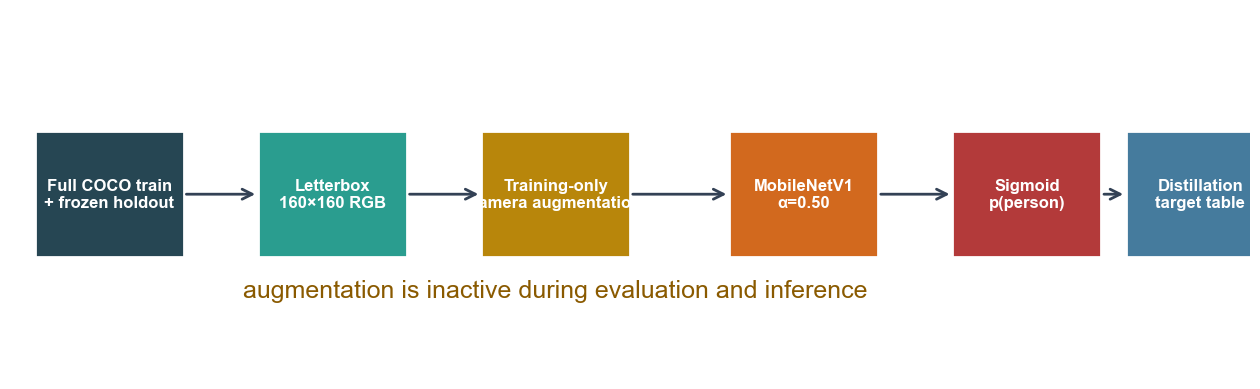

In [13]:
fig, ax = plt.subplots(figsize=(16, 4.8))
ax.axis("off")
nodes = [
    (0.02, "Full COCO train\n+ frozen holdout", "#264653"),
    (0.20, "Letterbox\n160×160 RGB", "#2a9d8f"),
    (0.38, "Training-only\ncamera augmentation", "#b8860b"),
    (0.58, "MobileNetV1\nα=0.50", "#d2691e"),
    (0.76, "Sigmoid\np(person)", "#b33a3a"),
    (0.90, "Distillation\ntarget table", "#457b9d"),
]
for x, label, color in nodes:
    ax.add_patch(plt.Rectangle(
        (x, 0.33), 0.12, 0.34, facecolor=color, edgecolor="white",
        linewidth=2, transform=ax.transAxes,
    ))
    ax.text(
        x + 0.06, 0.50, label, ha="center", va="center", color="white",
        fontsize=12, weight="bold", transform=ax.transAxes,
    )
for left, right in zip(nodes[:-1], nodes[1:]):
    ax.annotate(
        "", xy=(right[0], 0.50), xytext=(left[0] + 0.12, 0.50),
        xycoords=ax.transAxes,
        arrowprops={"arrowstyle": "->", "lw": 2, "color": "#334155"},
    )
ax.text(
    0.44, 0.22, "augmentation is inactive during evaluation and inference",
    ha="center", color="#8a5a00", transform=ax.transAxes,
)
fig.savefig(FIGURE_DIR / "teacher_evidence_flow.png", dpi=180, bbox_inches="tight")
plt.show()


## 14 · Profile static cost before optimization

These are graph estimates, not ESP32 measurements. The teacher is intentionally permitted to exceed MCU budgets.

In [14]:
layer_profile, activation_liveness, static_profile = profile_model(
    teacher, batch_size=1, training_batch_size=BATCH_SIZE
)
layer_profile.to_csv(REPORT_DIR / "teacher_layer_profile.csv", index=False)
activation_liveness.to_csv(
    REPORT_DIR / "teacher_activation_liveness.csv", index=False
)
(REPORT_DIR / "teacher_static_profile.json").write_text(
    json.dumps(static_profile, indent=2) + "\n"
)
pd.Series(static_profile)[[
    "parameters",
    "float32_weight_bytes",
    "estimated_macs_batch1",
    "peak_live_activation_int8_bytes_batch1_hypothetical",
]]


parameters                                               830049
float32_weight_bytes                                    3320196
estimated_macs_batch1                                  76013312
peak_live_activation_int8_bytes_batch1_hypothetical      414752
dtype: object

## 15 · Compile consistently and create validation-scored checkpoints

Stage A learns the binary head. Stage B fine-tunes late semantic layers while BatchNorm remains frozen to prevent small-batch statistic drift.

In [15]:
def compile_teacher(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(
            label_smoothing=float(config["training"]["label_smoothing"])
        ),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )

def callbacks(stage):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            CHECKPOINT_DIR / f"best_{stage}.keras",
            monitor="val_pr_auc", mode="max", save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_pr_auc", mode="max",
            patience=int(config["training"]["early_stopping_patience"]),
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_pr_auc", mode="max", factor=0.3,
            patience=int(config["training"]["reduce_lr_patience"]), min_lr=1e-7,
        ),
        tf.keras.callbacks.CSVLogger(ARTIFACT_DIR / "logs" / f"{stage}.csv"),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

for layer in teacher.layers:
    if layer.name in backbone_layer_names:
        layer.trainable = False
compile_teacher(
    teacher, float(config["training"]["frozen_backbone_learning_rate"])
)


## 16 · Stage A — train the classification head

This adapts ImageNet features to person/no-person before convolution filters are changed.

In [17]:
stage_a_path = CHECKPOINT_DIR / "best_stage_a.keras"

In [18]:
if stage_a_path.exists() and REUSE_BEST_CHECKPOINT:
    teacher = tf.keras.models.load_model(stage_a_path)
    history_a, stage_a_seconds = None, None
    print(f"Reused {stage_a_path}")
elif RUN_TRAINING:
    started = time.monotonic()
    history_a = teacher.fit(
        train_ds,
        validation_data=val_ds,
        epochs=int(config["training"]["frozen_backbone_epochs"]),
        callbacks=callbacks("stage_a"),
    )
    stage_a_seconds = time.monotonic() - started
else:
    history_a, stage_a_seconds = None, None
    print("Set RUN_TRAINING=True to execute Stage A.")


Reused /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/high_resolution_teacher_160_targeted_36k/checkpoints/best_stage_a.keras


## 17 · Stage B — selectively fine-tune late semantic features

Only the last configured MobileNet layers are unfrozen. All BatchNorm layers remain frozen.

In [20]:
stage_b_path = CHECKPOINT_DIR / "best_stage_b.keras"

In [21]:
if stage_b_path.exists() and REUSE_BEST_CHECKPOINT:
    teacher = tf.keras.models.load_model(stage_b_path, compile=False)
    history_b, stage_b_seconds = None, None
    teacher.save(MODEL_DIR / "teacher_160_targeted_36k.keras")
    print(f"Reused {stage_b_path}")
elif RUN_TRAINING:
    mobile_layers = [
        layer for layer in teacher.layers if layer.name in backbone_layer_names
    ]
    cutoff = max(
        0, len(mobile_layers) - int(config["training"]["fine_tune_last_layers"])
    )
    for index, layer in enumerate(mobile_layers):
        layer.trainable = (
            index >= cutoff
            and not isinstance(layer, tf.keras.layers.BatchNormalization)
        )
    compile_teacher(
        teacher, float(config["training"]["fine_tune_learning_rate"])
    )
    started = time.monotonic()
    history_b = teacher.fit(
        train_ds,
        validation_data=val_ds,
        epochs=int(config["training"]["fine_tune_epochs"]),
        callbacks=callbacks("stage_b"),
    )
    stage_b_seconds = time.monotonic() - started
    teacher = tf.keras.models.load_model(stage_b_path, compile=False)
    teacher.save(MODEL_DIR / "teacher_160_targeted_36k.keras")
else:
    history_b, stage_b_seconds = None, None
    print("Stage B awaits a Stage A run.")


Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 122s 106ms/step - accuracy: 0.7071 - loss: 0.5642 - pr_auc: 0.7901 - precision: 0.7090 - recall: 0.7024 - roc_auc: 0.7861 - val_accuracy: 0.8340 - val_loss: 0.4082 - val_pr_auc: 0.9225 - val_precision: 0.8544 - val_recall: 0.8008 - val_roc_auc: 0.9104 - learning_rate: 3.0000e-05
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 175s 155ms/step - accuracy: 0.7271 - loss: 0.5431 - pr_auc: 0.8141 - precision: 0.7332 - recall: 0.7141 - roc_auc: 0.8066 - val_accuracy: 0.8280 - val_loss: 0.3896 - val_pr_auc: 0.9328 - val_precision: 0.8006 - val_recall: 0.8686 - val_roc_auc: 0.9229 - learning_rate: 3.0000e-05
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 264s 235ms/step - accuracy: 0.7356 - loss: 0.5333 - pr_auc: 0.8237 - precision: 0.7440 - recall: 0.7186 - roc_auc: 0.8170 - val_accuracy: 0.8305 - val_loss: 0.3895 - val_pr_auc: 0.9295 - val_precision: 0.8450 - val_recall: 0.8049 - val_roc_auc: 0.9181 - learning_rate: 3.0000e-05
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━

## 18 · Visualize staged learning dynamics

The stage boundary is explicit so an optimizer reset cannot be mistaken for an architectural improvement.

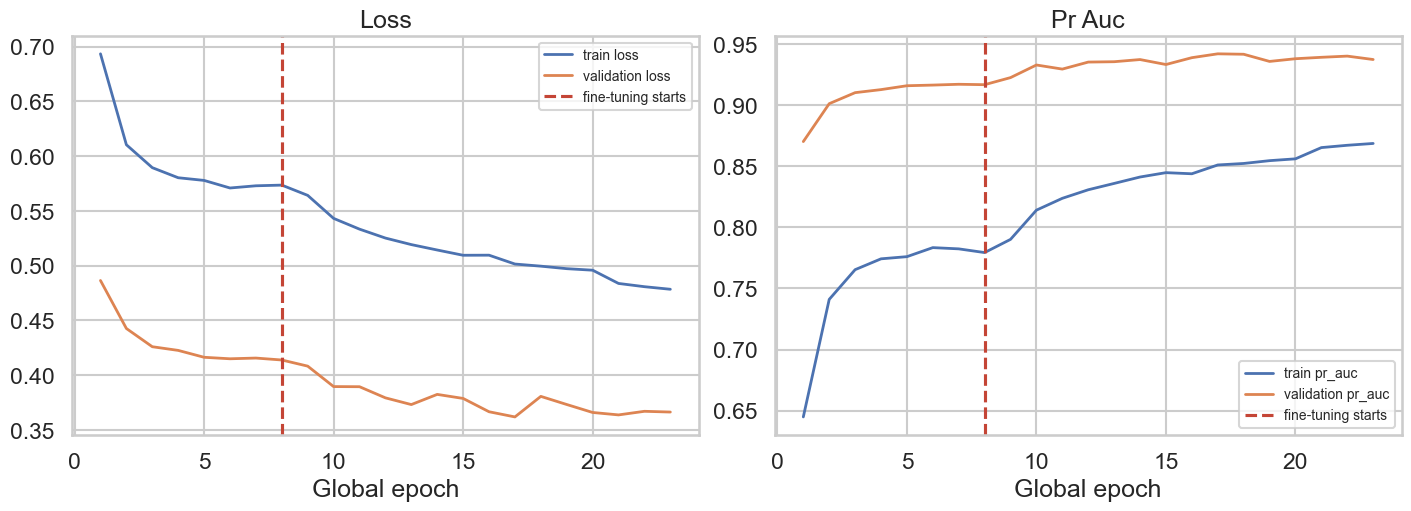

In [22]:
history_files = [
    ("head", ARTIFACT_DIR / "logs/stage_a.csv"),
    ("fine-tune", ARTIFACT_DIR / "logs/stage_b.csv"),
]
frames, epoch_offset = [], 0
for stage, path in history_files:
    if path.exists():
        frame = pd.read_csv(path)
        frame["stage"] = stage
        frame["global_epoch"] = np.arange(len(frame)) + epoch_offset + 1
        epoch_offset += len(frame)
        frames.append(frame)

if frames:
    learning = pd.concat(frames, ignore_index=True)
    stage_boundary = len(frames[0])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for metric, ax in (("loss", axes[0]), ("pr_auc", axes[1])):
        ax.plot(
            learning.global_epoch, learning[metric],
            label=f"train {metric}", linewidth=2,
        )
        ax.plot(
            learning.global_epoch, learning[f"val_{metric}"],
            label=f"validation {metric}", linewidth=2,
        )
        ax.axvline(
            stage_boundary, color="#c44536", linestyle="--",
            label="fine-tuning starts",
        )
        ax.set(xlabel="Global epoch", title=metric.replace("_", " ").title())
        ax.legend(fontsize=10)
    fig.savefig(FIGURE_DIR / "teacher_learning_curves.png", dpi=180)
    plt.show()
else:
    print("Learning curves will appear after training.")


## 19 · Select the operating threshold on validation only

A fixed threshold of 0.5 is not assumed. The test split stays untouched in this block.

In [23]:
def predict_dataset(model, dataset):
    labels = np.concatenate([
        np.asarray(batch_labels).reshape(-1)
        for _, batch_labels in dataset
    ])
    probabilities = model.predict(dataset, verbose=0).reshape(-1)
    return labels.astype(np.int8), probabilities.astype(np.float32)

FINAL_MODEL_PATH = MODEL_DIR / "teacher_160_targeted_36k.keras"
MODEL_READY = FINAL_MODEL_PATH.exists()
if MODEL_READY:
    teacher = tf.keras.models.load_model(FINAL_MODEL_PATH, compile=False)
    y_val, p_val = predict_dataset(teacher, val_ds)
    choice = select_threshold(
        y_val,
        p_val,
        objective=config["evaluation"]["threshold_objective"],
        minimum_recall=float(config["evaluation"]["minimum_recall"]),
        false_positive_cost=float(config["evaluation"]["false_positive_cost"]),
        false_negative_cost=float(config["evaluation"]["false_negative_cost"]),
    )
    THRESHOLD = float(choice["threshold"])
    validation_metrics = classification_metrics(y_val, p_val, THRESHOLD)
    validation_metrics["expected_calibration_error_10_bins"] = (
        expected_calibration_error(y_val, p_val)
    )
    (REPORT_DIR / "validation_metrics.json").write_text(
        json.dumps(validation_metrics, indent=2) + "\n"
    )
    display(pd.Series(validation_metrics))
else:
    THRESHOLD, validation_metrics = None, None
    print("Evaluation is gated until teacher_160_targeted_36k.keras exists.")


samples                                                   2000
threshold                                                  0.5
accuracy                                                0.8505
precision                                             0.848485
recall                                                0.849343
f1                                                    0.848914
roc_auc                                               0.934029
pr_auc                                                0.942015
specificity                                           0.851632
confusion_matrix                      [[861, 150], [149, 840]]
positive_prevalence                                     0.4945
predicted_positive_rate                                  0.495
expected_calibration_error_10_bins                      0.0596
dtype: object

## 20 · Open held-out test once and compare with frozen baselines

The decisive comparison is against Notebook 01's 12,000-image 160×160 teacher on the exact same test IDs. The 96×96 and Fast-80 INT8 reports remain context. Every model keeps its own validation-selected threshold.

In [24]:
baseline_paths = {
    "baseline_96_int8": ROOT / "artifacts/reports/test_metrics.json",
    "fast_80_int8": ROOT / "artifacts/fast_80/reports/test_metrics_int8.json",
    "subset_teacher_160_float": ROOT / config["teacher_gate"]["reference_report"],
}
baselines = {
    name: json.loads(path.read_text())
    for name, path in baseline_paths.items()
}

if MODEL_READY:
    y_test, p_test = predict_dataset(teacher, test_ds)
    test_metrics = classification_metrics(y_test, p_test, THRESHOLD)
    test_metrics["expected_calibration_error_10_bins"] = (
        expected_calibration_error(y_test, p_test)
    )
    (REPORT_DIR / "test_metrics.json").write_text(
        json.dumps(test_metrics, indent=2) + "\n"
    )
    comparison = pd.DataFrame({
        **baselines,
        "targeted_36k_teacher_160_float": test_metrics,
    }).T
    comparison.index.name = "model"
    comparison.to_csv(REPORT_DIR / "baseline_comparison.csv")
    display(comparison[[
        "accuracy", "precision", "recall", "specificity",
        "f1", "pr_auc", "roc_auc",
    ]].style.format("{:.3f}"))
else:
    y_test = p_test = test_metrics = comparison = None
    display(pd.DataFrame(baselines).T[[
        "accuracy", "precision", "recall", "specificity", "f1", "pr_auc",
    ]])


,accuracy,precision,recall,specificity,f1,pr_auc,roc_auc
model,,,,,,,
baseline_96_int8,0.691,0.645,0.824,0.563,0.723,0.803,0.801
fast_80_int8,0.657,0.601,0.898,0.426,0.720,0.787,0.788
subset_teacher_160_float,0.852,0.859,0.834,0.868,0.846,0.930,0.921
targeted_36k_teacher_160_float,0.842,0.856,0.815,0.868,0.835,0.930,0.922


## 21 · Plot quality differences, calibration, and errors

Aggregate metrics, confusion, ranking, and reliability are shown together so threshold movement cannot masquerade as genuine representation improvement.

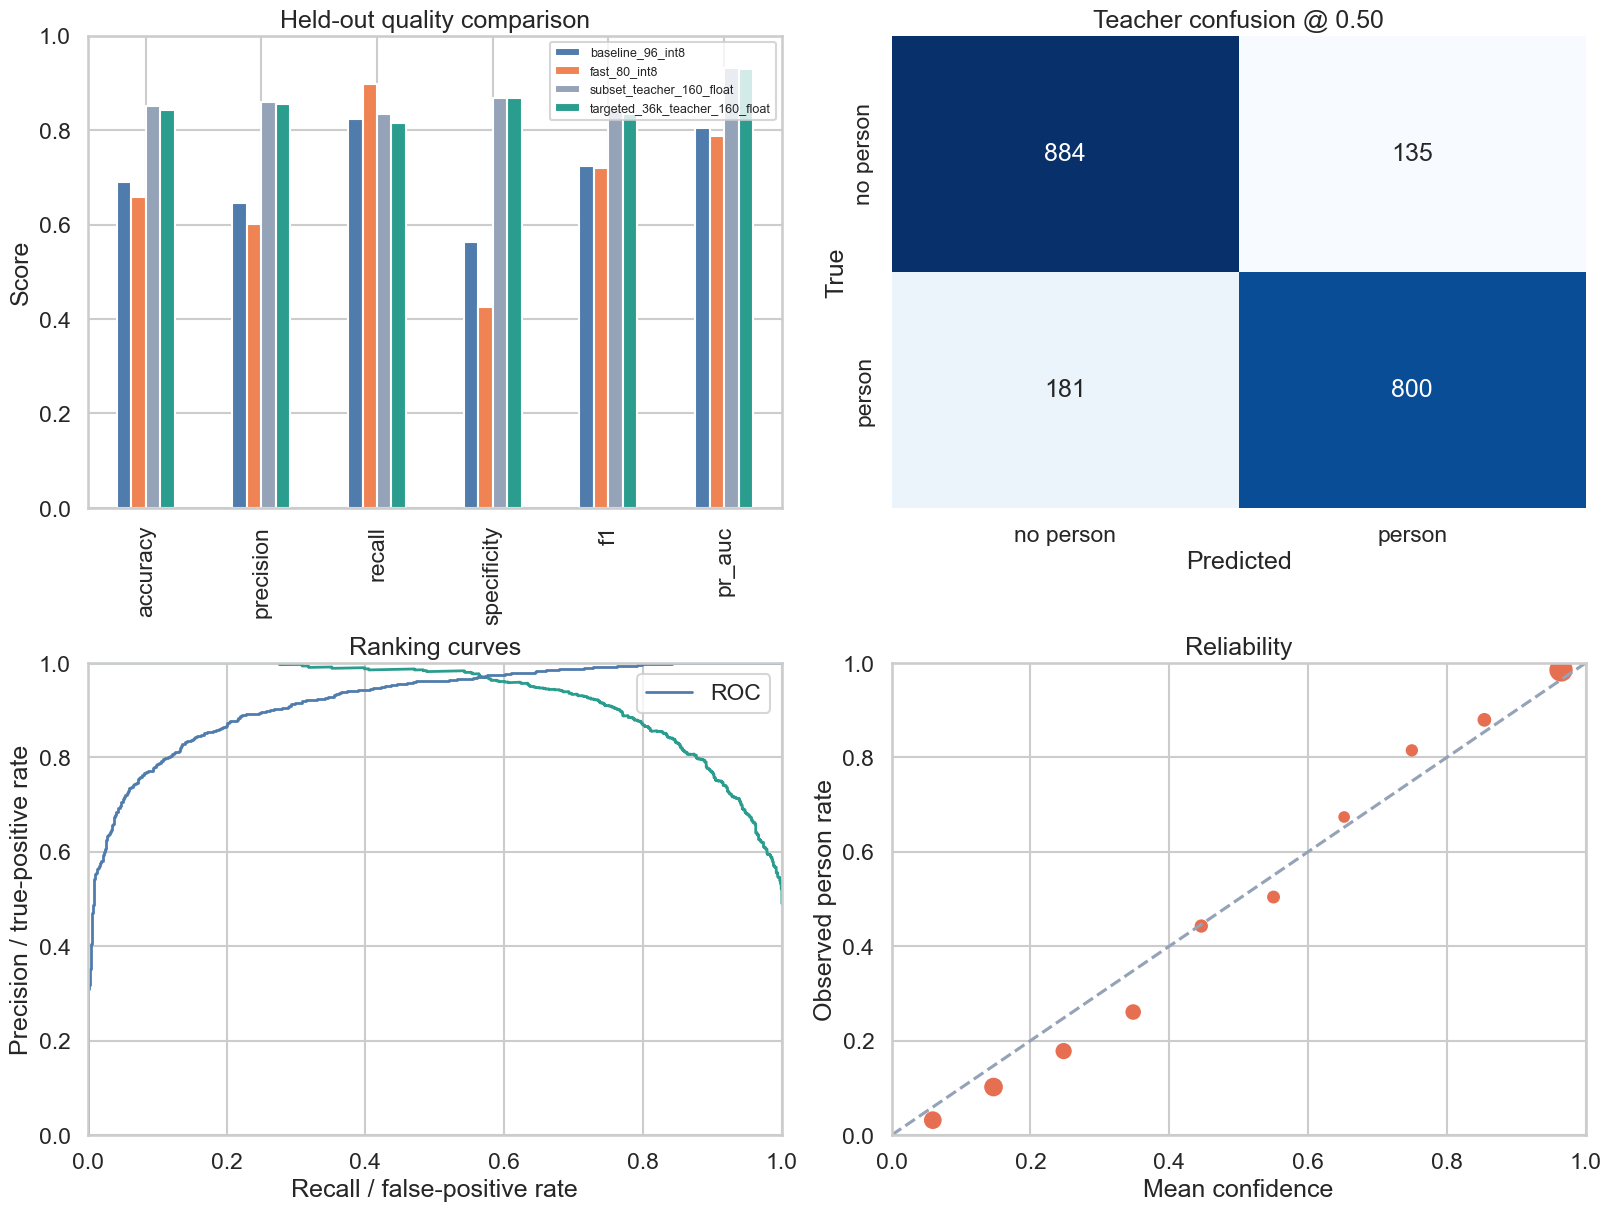

In [25]:
if MODEL_READY:
    metrics_to_plot = [
        "accuracy", "precision", "recall", "specificity", "f1", "pr_auc"
    ]
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)

    comparison[metrics_to_plot].astype(float).T.plot(
        kind="bar", ax=axes[0, 0], ylim=(0, 1),
        color=["#4f7cac", "#ef8354", "#94a3b8", "#2a9d8f"],
    )
    axes[0, 0].set(title="Held-out quality comparison", ylabel="Score")
    axes[0, 0].legend(fontsize=9)

    confusion = np.asarray(test_metrics["confusion_matrix"])
    sns.heatmap(
        confusion, annot=True, fmt="d", cmap="Blues", cbar=False,
        ax=axes[0, 1], xticklabels=["no person", "person"],
        yticklabels=["no person", "person"],
    )
    axes[0, 1].set(
        title=f"Teacher confusion @ {THRESHOLD:.2f}",
        xlabel="Predicted", ylabel="True",
    )

    precision, recall, _ = precision_recall_curve(y_test, p_test)
    fpr, tpr, _ = roc_curve(y_test, p_test)
    axes[1, 0].plot(recall, precision, color="#2a9d8f", linewidth=2)
    axes[1, 0].plot(fpr, tpr, color="#4f7cac", linewidth=2, label="ROC")
    axes[1, 0].set(
        xlabel="Recall / false-positive rate", ylabel="Precision / true-positive rate",
        title="Ranking curves", xlim=(0, 1), ylim=(0, 1),
    )
    axes[1, 0].legend()

    bins = np.linspace(0, 1, 11)
    bin_id = np.clip(np.digitize(p_test, bins) - 1, 0, 9)
    calibration = pd.DataFrame({
        "label": y_test, "probability": p_test, "bin": bin_id,
    }).groupby("bin").agg(
        confidence=("probability", "mean"),
        observed=("label", "mean"),
        samples=("label", "size"),
    ).reset_index()
    calibration.to_csv(REPORT_DIR / "calibration_bins.csv", index=False)
    axes[1, 1].plot([0, 1], [0, 1], "--", color="#94a3b8")
    axes[1, 1].scatter(
        calibration.confidence, calibration.observed,
        s=np.maximum(30, calibration.samples / 2), color="#e76f51",
    )
    axes[1, 1].set(
        xlabel="Mean confidence", ylabel="Observed person rate",
        title="Reliability", xlim=(0, 1), ylim=(0, 1),
    )
    fig.savefig(FIGURE_DIR / "teacher_quality_dashboard.png", dpi=180)
    plt.show()
else:
    print("Quality dashboard will appear after evaluation.")


## 22 · Slice errors by person size, brightness, and aspect ratio

If resolution is helping, the smallest-person slice should improve rather than only the global threshold changing.

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Volumes/VM_SSD/Machine Learning/v

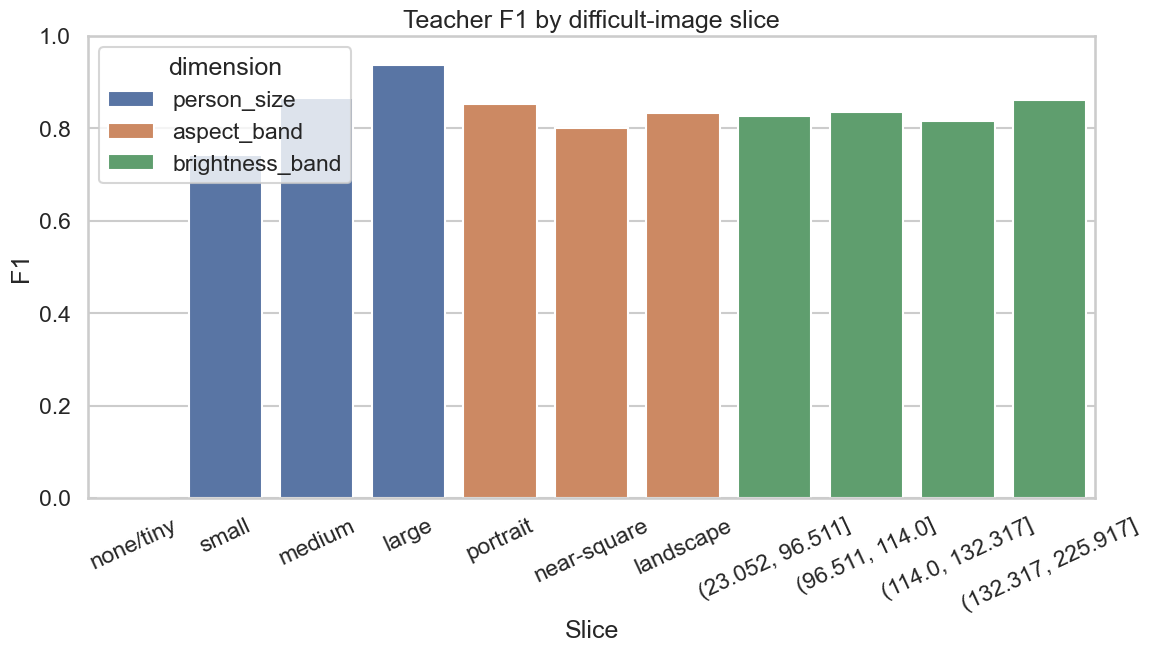

In [26]:
if MODEL_READY:
    error_frame = splits["test"].copy()
    error_frame["probability"] = p_test
    error_frame["prediction"] = (p_test >= THRESHOLD).astype(np.int8)
    error_frame["correct"] = error_frame.prediction == error_frame.label
    error_frame["person_size"] = pd.cut(
        error_frame.max_person_area_fraction,
        bins=[-1e-9, 0.005, 0.025, 0.10, 1.0],
        labels=["none/tiny", "small", "medium", "large"],
    )
    if "brightness" in error_frame:
        error_frame["brightness_band"] = pd.qcut(
            error_frame.brightness, q=4, duplicates="drop"
        )
    error_frame["aspect_band"] = pd.cut(
        error_frame.aspect_ratio,
        bins=[0, 0.8, 1.25, np.inf],
        labels=["portrait", "near-square", "landscape"],
    )

    dimensions = ["person_size", "aspect_band"]
    if "brightness_band" in error_frame:
        dimensions.append("brightness_band")
    rows = []
    for dimension in dimensions:
        for value, group in error_frame.groupby(dimension, observed=True):
            metrics = classification_metrics(
                group.label.to_numpy(), group.probability.to_numpy(), THRESHOLD
            )
            rows.append({"dimension": dimension, "slice": str(value), **metrics})
    error_slices = pd.DataFrame(rows)
    error_slices.to_csv(REPORT_DIR / "error_slices.csv", index=False)

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.barplot(
        data=error_slices, x="slice", y="f1", hue="dimension", ax=ax
    )
    ax.set(
        title="Teacher F1 by difficult-image slice",
        xlabel="Slice", ylabel="F1", ylim=(0, 1),
    )
    ax.tick_params(axis="x", rotation=25)
    fig.savefig(
        FIGURE_DIR / "teacher_error_slices.png",
        dpi=180, bbox_inches="tight",
    )
    plt.show()
else:
    error_frame = error_slices = None
    print("Error slices will appear after evaluation.")


## 23 · Export distillation targets

Student training may use train probabilities, validation tunes student settings, and test remains final-only. Logits are clipped for numerical stability.

In [27]:
if MODEL_READY:
    target_frames = []
    for split_name, dataset in (
        ("train", train_eval_ds), ("val", val_ds), ("test", test_ds)
    ):
        labels_for_split, probabilities = predict_dataset(teacher, dataset)
        frame = splits[split_name][[
            "image_id", "split", "label", "image_path"
        ]].copy()
        assert np.array_equal(frame.label.to_numpy(), labels_for_split)
        frame["teacher_probability"] = probabilities
        clipped = np.clip(probabilities, 1e-6, 1 - 1e-6)
        frame["teacher_logit"] = np.log(clipped / (1 - clipped))
        target_frames.append(frame)
    distillation_targets = pd.concat(target_frames, ignore_index=True)
    distillation_targets.to_csv(
        ARTIFACT_DIR / "teacher_distillation_targets.csv", index=False
    )
    print(distillation_targets.groupby("split").teacher_probability.agg(
        ["count", "mean", "std"]
    ))
else:
    distillation_targets = None
    print("Distillation export is gated until the teacher exists.")


       count      mean       std
split                           
test    2000  0.507715  0.340948
train  36000  0.482915  0.322378
val     2000  0.525365  0.342297


## 24 · Apply the pre-registered teacher acceptance gate

The targeted-36k teacher must improve PR-AUC and F1 over the 12,000-image teacher without buying accuracy through a material specificity collapse.

In [28]:
if MODEL_READY:
    baseline = baselines["subset_teacher_160_float"]
    gate_cfg = config["teacher_gate"]
    gates = {
        "pr_auc_gain": (
            test_metrics["pr_auc"] - baseline["pr_auc"]
            >= float(gate_cfg["minimum_pr_auc_gain_vs_reference"])
        ),
        "f1_gain": (
            test_metrics["f1"] - baseline["f1"]
            >= float(gate_cfg["minimum_f1_gain_vs_reference"])
        ),
        "specificity_retained": (
            test_metrics["specificity"]
            >= baseline["specificity"]
            - float(gate_cfg["maximum_specificity_drop"])
        ),
    }
    gate_table = pd.DataFrame({
        "gate": gates.keys(), "passed": gates.values()
    })
    display(gate_table)
else:
    gates = None
    print("Acceptance gates will run after test evaluation.")


,gate,passed
0,pr_auc_gain,False
1,f1_gain,False
2,specificity_retained,True


## 25 · Write machine-readable and human reports

Measured quality and estimated resources are kept separate. The teacher is approved only as a distillation source, never as an ESP32 deployment artifact.

In [29]:
if MODEL_READY:
    summary = {
        "experiment": "high_resolution_teacher_160_targeted_36k",
        "runtime_contract": runtime_contract,
        "architecture": {
            "family": "MobileNetV1",
            "alpha": float(config["model"]["width_multiplier"]),
            "input": [160, 160, 3],
            "initialization": "ImageNet",
        },
        "validation_threshold": THRESHOLD,
        "validation_metrics": validation_metrics,
        "test_metrics": test_metrics,
        "subset_teacher_160_metrics": baselines["subset_teacher_160_float"],
        "baseline_96_metrics": baselines["baseline_96_int8"],
        "static_profile": static_profile,
        "acceptance_gates": gates,
        "approved_for_distillation": bool(all(gates.values())),
    }
    (REPORT_DIR / "experiment_summary.json").write_text(
        json.dumps(summary, indent=2) + "\n"
    )
    report = f"""# Targeted-36k high-resolution VWW teacher report

- Input: 160×160 RGB with aspect-ratio-preserving letterbox
- Architecture: MobileNetV1 α=0.50, ImageNet initialized
- Training images: {len(splits['train']):,} (subset teacher: {len(reference[reference.split == 'train']):,})
- Validation-selected threshold: {THRESHOLD:.3f}
- Test PR-AUC: {test_metrics['pr_auc']:.4f} (subset teacher: {baselines['subset_teacher_160_float']['pr_auc']:.4f})
- Test F1: {test_metrics['f1']:.4f} (subset teacher: {baselines['subset_teacher_160_float']['f1']:.4f})
- Test specificity: {test_metrics['specificity']:.4f} (subset teacher: {baselines['subset_teacher_160_float']['specificity']:.4f})
- Approved for distillation: **{all(gates.values())}**

This teacher is not an ESP32 deployment artifact. Compare it with Notebook 01
to measure the value of dataset scale before choosing the source teacher for
student distillation and later INT8 deployment.
"""
    (REPORT_DIR / "TARGETED_36K_TEACHER_REPORT.md").write_text(report)
    display(Markdown(report))
else:
    print("Summary generation is gated until training and evaluation finish.")


# Targeted-36k high-resolution VWW teacher report

- Input: 160×160 RGB with aspect-ratio-preserving letterbox
- Architecture: MobileNetV1 α=0.50, ImageNet initialized
- Training images: 36,000 (subset teacher: 12,000)
- Validation-selected threshold: 0.500
- Test PR-AUC: 0.9301 (subset teacher: 0.9305)
- Test F1: 0.8351 (subset teacher: 0.8464)
- Test specificity: 0.8675 (subset teacher: 0.8685)
- Approved for distillation: **False**

This teacher is not an ESP32 deployment artifact. Compare it with Notebook 01
to measure the value of dataset scale before choosing the source teacher for
student distillation and later INT8 deployment.


## 26 · Hand-off

If the targeted-36k teacher passes all gates, it replaces Notebook 01 as the distillation source. If it fails, compare small-person recall, hard negatives, calibration, and learning curves before changing resolution or architecture. Do not quantize or prune this teacher simply to force it onto an ESP32; its job is to define and transfer the accuracy ceiling.